# “I implemented linear regression using both sklearn and gradient descent. Sklearn computes parameters analytically, while gradient descent iteratively updates parameters using partial derivatives of the loss function. Both approaches converge to similar results, validating the implementation.”

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.preprocessing import StandardScaler

In [80]:
df = pd.read_csv("Height-Weight Data.csv")
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
3496,69.296830,185.649086
3497,70.542201,210.198845
3498,73.912549,202.429960
3499,67.396021,144.277671


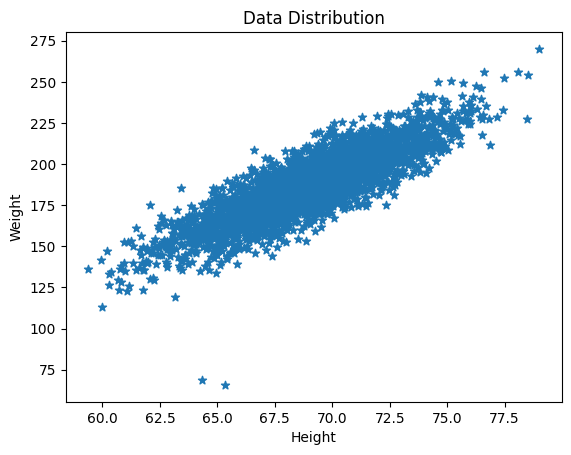

In [81]:
plt.scatter(df['Height'], df['Weight'], marker='*')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title("Data Distribution")
plt.show()

In [85]:
from sklearn.model_selection import train_test_split

X = df[['Height']]
y = df['Weight']

xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(xtrain, ytrain)   # ✅ TRAIN FIRST

pred = lr.predict(xtest) # ✅ THEN PREDICT

In [87]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(ytest, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(ytest, pred)
r2 = r2_score(ytest, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 9.8598937688493
MAE: 8.040126312816263
R2: 0.7461790585161445


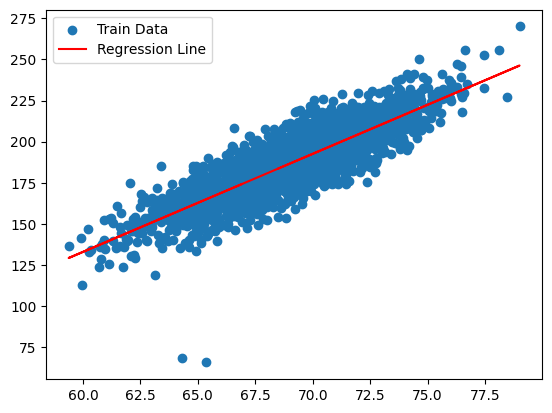

In [88]:
plt.scatter(xtrain, ytrain, label="Train Data")
plt.plot(xtrain, lr.predict(xtrain), color='red', label="Regression Line")
plt.legend()
plt.show()

In [89]:
#x = xtrain.values.flatten()
#y = ytrain.values.flatten()
x = df['Height'].values.reshape(-1)
y = df['Weight'].values.reshape(-1)

x_scaled = (x - np.mean(x)) / np.std(x)

In [93]:
# Initialization of Parameters
m = 0 # slope
c = 0 # intercept
lr_rate = 0.01 # learning rate
n = len(x)  # number of samples

for i in range(10000):
    
    pred = m * x + c # Defnine Model y = mx+c
    
    # Loss
    loss = (1/n) * np.sum((y - pred)**2) # Loss Function - MSE
    
    # # Compute Gradients
    dm = (-2/n) * np.sum(x * (y - pred))
    dc = (-2/n) * np.sum(y - pred)
    
    # # Update Parameters
    m -= lr_rate * dm
    c -= lr_rate * dc
    
    if i % 100 == 0:
        print(f"Iter {i}: Loss={loss}")

Iter 0: Loss=35324.363808872055
Iter 100: Loss=inf
Iter 200: Loss=nan
Iter 300: Loss=nan
Iter 400: Loss=nan
Iter 500: Loss=nan
Iter 600: Loss=nan
Iter 700: Loss=nan
Iter 800: Loss=nan
Iter 900: Loss=nan
Iter 1000: Loss=nan
Iter 1100: Loss=nan
Iter 1200: Loss=nan
Iter 1300: Loss=nan
Iter 1400: Loss=nan
Iter 1500: Loss=nan


C:\Program Files\Python313\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Qbits\AppData\Local\Temp\ipykernel_10704\4143468476.py:12: RuntimeWarning: overflow encountered in square
  loss = (1/n) * np.sum((y - pred)**2) # Loss Function - MSE
C:\Users\Qbits\AppData\Local\Temp\ipykernel_10704\4143468476.py:19: RuntimeWarning: invalid value encountered in scalar subtract
  m -= lr_rate * dm


Iter 1600: Loss=nan
Iter 1700: Loss=nan
Iter 1800: Loss=nan
Iter 1900: Loss=nan
Iter 2000: Loss=nan
Iter 2100: Loss=nan
Iter 2200: Loss=nan
Iter 2300: Loss=nan
Iter 2400: Loss=nan
Iter 2500: Loss=nan
Iter 2600: Loss=nan
Iter 2700: Loss=nan
Iter 2800: Loss=nan
Iter 2900: Loss=nan
Iter 3000: Loss=nan
Iter 3100: Loss=nan
Iter 3200: Loss=nan
Iter 3300: Loss=nan
Iter 3400: Loss=nan
Iter 3500: Loss=nan
Iter 3600: Loss=nan
Iter 3700: Loss=nan
Iter 3800: Loss=nan
Iter 3900: Loss=nan
Iter 4000: Loss=nan
Iter 4100: Loss=nan
Iter 4200: Loss=nan
Iter 4300: Loss=nan
Iter 4400: Loss=nan
Iter 4500: Loss=nan
Iter 4600: Loss=nan
Iter 4700: Loss=nan
Iter 4800: Loss=nan
Iter 4900: Loss=nan
Iter 5000: Loss=nan
Iter 5100: Loss=nan
Iter 5200: Loss=nan
Iter 5300: Loss=nan
Iter 5400: Loss=nan
Iter 5500: Loss=nan
Iter 5600: Loss=nan
Iter 5700: Loss=nan
Iter 5800: Loss=nan
Iter 5900: Loss=nan
Iter 6000: Loss=nan
Iter 6100: Loss=nan
Iter 6200: Loss=nan
Iter 6300: Loss=nan
Iter 6400: Loss=nan
Iter 6500: Loss=nan


In [94]:
print("Sklearn slope:", lr.coef_[0])
print("Sklearn intercept:", lr.intercept_)

print("Gradient Descent slope:", m)
print("Gradient Descent intercept:", c)

Sklearn slope: 5.962329125895918
Sklearn intercept: -224.7732969939356
Gradient Descent slope: nan
Gradient Descent intercept: nan


In [95]:
# mean and std of original x
mu = np.mean(x)
sigma = np.std(x)

# convert GD parameters
m_original = m / sigma
c_original = c - (m * mu / sigma)

print("Converted GD slope:", m_original)
print("Converted GD intercept:", c_original)

Converted GD slope: nan
Converted GD intercept: nan
